<div class="alert alert-block alert-info" style="padding:20px;color:white;margin:auto;font-size:300%;text-align:center;display:fill;border-radius:60px;background-color:#37006f;overflow:hidden;font-weight:800">VGG Audio Classifier</div>

In [1]:
cd ..

d:\Personal Projects\tune-ml


d:\Personal Projects\tune-ml\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
!python --version

Python 3.10.11


### 1. Setup

In [3]:
import os
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt
from typing import Tuple

import torch
import torch.nn as nn
import torchaudio.transforms as T

import logging
import warnings

# Suppress MLflow warnings
logging.getLogger("mlflow").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

In [4]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("VGG Audio Classifier")

# Enable system metrics logging
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)  # Log system metrics every 1 second

2026/04/13 15:55:44 INFO mlflow.tracking.fluent: Experiment with name 'VGG Audio Classifier' does not exist. Creating a new experiment.


### 2. Utils

In [5]:
def padding(array, xx, yy):
    """
    Pads the input array to the target shape (xx, yy) with zeros.
    
    :param array: The input array to be padded.
    :type array: np.ndarray
    :param xx: The target number of rows.
    :type xx: int
    :param yy: The target number of columns.
    :type yy: int
    
    :return: The padded array with shape (xx, yy).
    :rtype: np.ndarray
    """
    h = array.shape[0]
    w = array.shape[1]
    
    # Trim if larger than target
    if h > xx:
        array = array[:xx, :]
        h = xx
    if w > yy:
        array = array[:, :yy]
        w = yy

    # Pad if smaller than target
    a = (xx - h) // 2
    aa = (xx - h) - a
    b = (yy - w) // 2
    bb = (yy - w) - b
    
    return np.pad(array, ((a, aa), (b, bb)), mode='constant', constant_values=0)

In [6]:
def load_audio(file_path: str, target_sr: int = 22050) -> Tuple[np.ndarray, int]:
    """
    Loads an audio file and resamples it to the target sample rate.
    
    :param file_path: The path to the audio file.
    :type file_path: str
    :param target_sr: The target sample rate for resampling (default is 22050).
    :type target_sr: int
    
    :return: A tuple containing the audio waveform as a numpy array and the sample rate.
    :rtype: Tuple[np.ndarray, int]
    """
    waveform, sr = sf.read(file_path)
    
    # Resample if the original sample rate is different from the target sample rate
    if sr != target_sr:
        waveform = librosa.resample(waveform.astype(float), orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    
    # Convert to PyTorch tensor        
    waveform = torch.tensor(waveform, dtype=torch.float32)

    # Handle mono and stereo audio
    if waveform.ndim == 1:  # Mono audio
        waveform = waveform.unsqueeze(0)  # Add channel dimension
    elif waveform.ndim == 2 and waveform.shape[1] == 2:  # Stereo audio
        waveform = waveform.T  # Transpose to (channels, samples)
    else:
        raise ValueError(f"Unsupported audio format with shape {waveform.shape}")
    
    return waveform, sr

### 3. Data Visualization

In [9]:
df = pd.read_csv("./datasets/audio_classifier/esc50.csv")
df.head(10)

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
5,1-101296-B-19.wav,1,19,thunderstorm,False,101296,B
6,1-101336-A-30.wav,1,30,door_wood_knock,False,101336,A
7,1-101404-A-34.wav,1,34,can_opening,False,101404,A
8,1-103298-A-9.wav,1,9,crow,False,103298,A
9,1-103995-A-30.wav,1,30,door_wood_knock,False,103995,A


In [11]:
# Display a sample of the dataset
sample_num = 3
# get the filename of the sample
filename = df.iloc[sample_num]["filename"]
audio_path = os.path.join("./datasets/audio_classifier/audio", filename)
ipd.display(ipd.Audio(audio_path))

Sample 3 - Filename: 1-100210-B-36.wav, Sample Rate: 44100, Audio Length: 5.00 seconds


Text(0.5, 14.722222222222216, 'Time (seconds)')

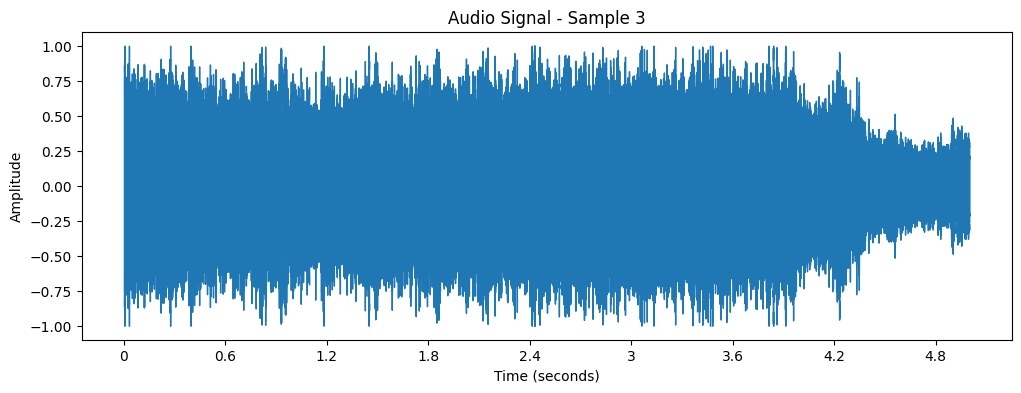

In [12]:
# Load the audio file and display its properties
signal, sr = librosa.load(audio_path, sr=None)
print(f"Sample {sample_num} - Filename: {filename}, Sample Rate: {sr}, Audio Length: {len(signal)/sr:.2f} seconds")
# Plot the audio signal
plt.figure(figsize=(12, 4))
librosa.display.waveshow(signal, sr=sr)
plt.title(f"Audio Signal - Sample {sample_num}")
plt.ylabel("Amplitude")
plt.xlabel("Time (seconds)")

FFT Length: 220500, Frequency Range: 0 - 44100 Hz


Text(0.5, 1.0, 'FFT Magnitude - Sample 3')

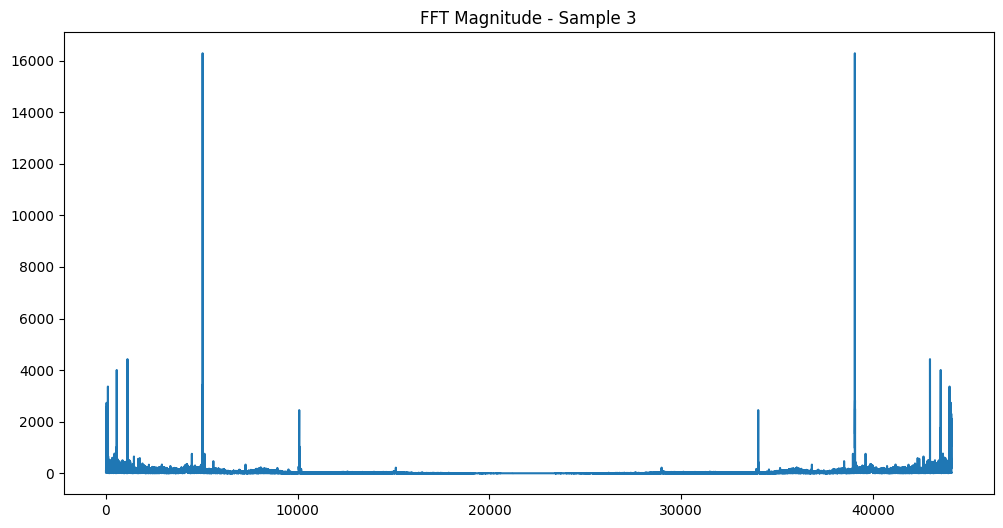

In [13]:
# Derive frequency spectrum using Fast Fourier Transform (FFT)
fft = np.fft.fft(signal)
magnitude = np.abs(fft) # Magnitude of the FFT
frequency = np.linspace(0, sr, len(magnitude)) # Frequency bins corresponding to the FFT values
print(f"FFT Length: {len(fft)}, Frequency Range: 0 - {sr} Hz")
# Plot the magnitude of the FFT
plt.figure(figsize=(12, 6))
plt.plot(frequency, magnitude)
plt.title(f"FFT Magnitude - Sample {sample_num}")

In [14]:
print(f"Signal Length: {len(signal)}, Sample Rate: {sr}, Duration: {len(signal)/sr:.2f} seconds")

Signal Length: 220500, Sample Rate: 44100, Duration: 5.00 seconds


STFT Shape: (1025, 431)


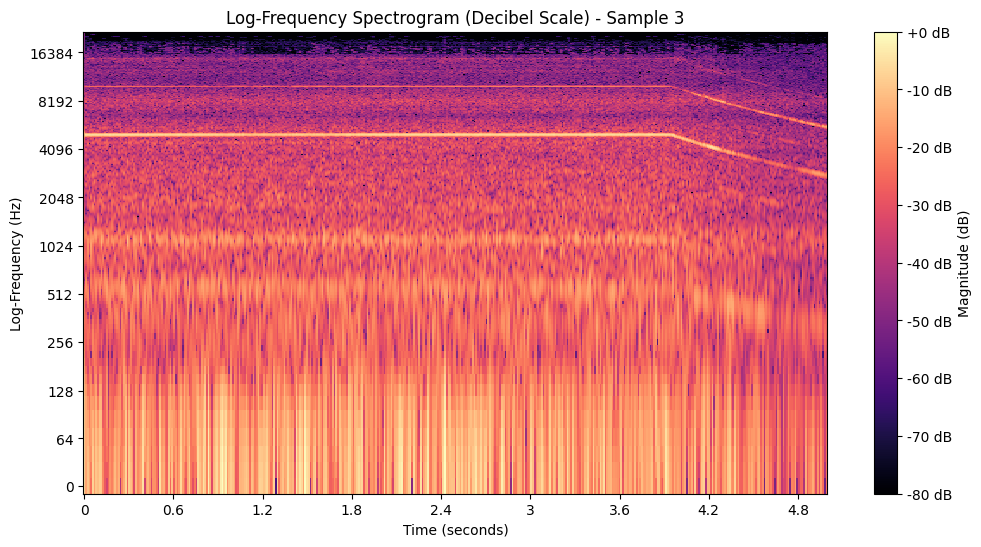

In [15]:
# Derive Short-Time Fourier Transform (STFT)
stft = librosa.stft(signal, n_fft=2048, hop_length=512, win_length=512)
# Display the shape of the STFT
print(f"STFT Shape: {stft.shape}")
# Plot the magnitude of the STFT
plt.figure(figsize=(12, 6))
librosa.display.specshow(
    librosa.amplitude_to_db(np.abs(stft), ref=np.max), 
    sr=sr, 
    x_axis='time',  
    y_axis='log'
)
plt.title(f"Log-Frequency Spectrogram (Decibel Scale) - Sample {sample_num}")
plt.xlabel("Time (seconds)")
plt.ylabel("Log-Frequency (Hz)")
cbar = plt.colorbar(format="%+2.0f dB")
cbar.set_label("Magnitude (dB)")

Mel Spectrogram Shape: (128, 431)


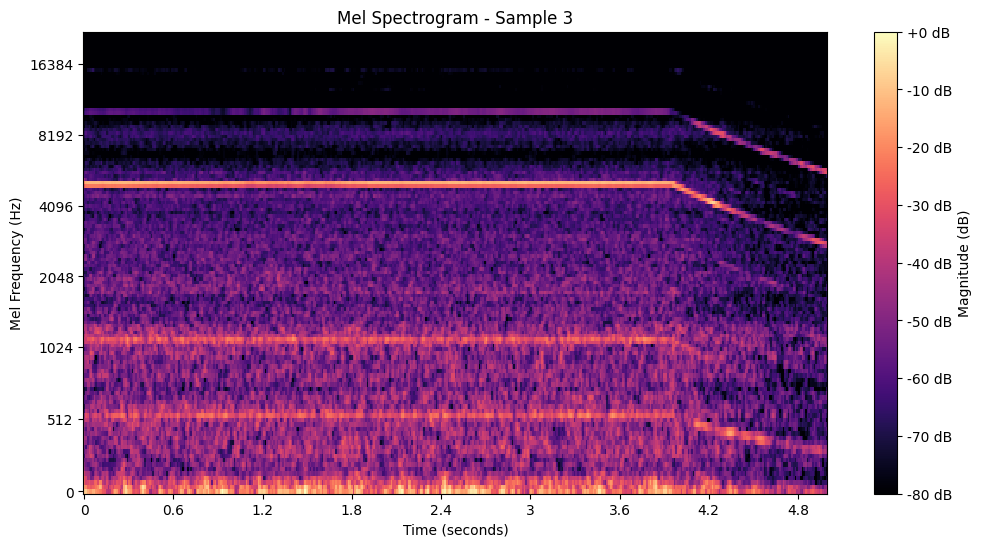

In [16]:
# Generate the Mel Spectrogram
# y: Audio time series
# sr: Sampling rate of y
# n_mels: Number of Mel bands to generate (default: 128)
mel_spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
print(f"Mel Spectrogram Shape: {mel_spectrogram.shape}")
# Plot the Mel Spectrogram
plt.figure(figsize=(12, 6))
librosa.display.specshow(
    librosa.amplitude_to_db(mel_spectrogram, ref=np.max), 
    sr=sr,
    x_axis='time',      # X-axis: Time axis in seconds
    y_axis='mel',       # Y-axis: Mel frequency axis
    cmap="magma"        # Use a perceptually uniform colormap
)
plt.title(f"Mel Spectrogram - Sample {sample_num}")
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency (Hz)")
cbar = plt.colorbar(format="%+2.0f dB")
cbar.set_label("Magnitude (dB)")

In [17]:
mel_spectrogram = T.MelSpectrogram(
    sample_rate=22050,
    n_fft=2048,             # FFT window size (number of samples per FFT)
    hop_length=512,         # Number of samples between successive frames (hop length)
    n_mels=128              # Number of Mel bands to generate (default: 128)
)
print(f"Mel Spectrogram Transform: {mel_spectrogram}")

to_db = T.AmplitudeToDB()

waveform, sample_rate = load_audio(audio_path)
print(f"Waveform Shape: {waveform.shape}, Sample Rate: {sample_rate}")

mel = mel_spectrogram(waveform)
print(f"Mel Spectrogram Shape: {mel.shape}")

mel = to_db(mel)
print(f"Mel Spectrogram in dB Shape: {mel.shape}")

mel = mel.squeeze(0).numpy()
print(f"Mel Spectrogram after Squeeze Shape: {mel.shape}")


Mel Spectrogram Transform: MelSpectrogram(
  (spectrogram): Spectrogram()
  (mel_scale): MelScale()
)
Waveform Shape: torch.Size([1, 110250]), Sample Rate: 22050
Mel Spectrogram Shape: torch.Size([1, 128, 216])
Mel Spectrogram in dB Shape: torch.Size([1, 128, 216])
Mel Spectrogram after Squeeze Shape: (128, 216)


## 6. Model Training

In [18]:
batch_size = 32
learning_rate = 1e-3
max_learning_rate = 1e-2
num_epochs = 100
checkpoint_path = "weights/best_mini_vgg.pth"

In [20]:
from tuneml.trainers.MiniVGGTrainer import MiniVGGTrainer
from tuneml.data.esc50 import ESC50Dataset

train_transform = nn.Sequential(
    T.MelSpectrogram(
        sample_rate=22050,
        n_fft=2048,
        hop_length=512,
        n_mels=128,
        f_min=0,
        f_max=11025
    ),
    T.AmplitudeToDB(),
    T.FrequencyMasking(freq_mask_param=15),
    T.TimeMasking(time_mask_param=35)
)

val_transform = nn.Sequential(
    T.MelSpectrogram(
        sample_rate=22050,
        n_fft=2048,
        hop_length=512,
        n_mels=128,
        f_min=0,
        f_max=11025
    ),
    T.AmplitudeToDB()
)

data_dir = "./datasets/audio_classifier/audio"
train_dataset = ESC50Dataset(
    data_dir=data_dir,
    metadata_file="./datasets/audio_classifier/esc50.csv",
    split="train",
    transform=train_transform
)
print("Training samples:", len(train_dataset))

test_dataset = ESC50Dataset(
    data_dir=data_dir,
    metadata_file="./datasets/audio_classifier/esc50.csv", 
    split="test",
    transform=val_transform
)
print("Test samples:", len(test_dataset))


Training samples: 1600
Test samples: 400


In [21]:
trainer = MiniVGGTrainer(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    batch_size=batch_size,
    lr=learning_rate,
    max_lr=max_learning_rate,
    ckpt_path=checkpoint_path,
    load_from_checkpoint=False,
    mixup_alpha=0.2,
    mixup_probability=0.3,
    label_smoothing=0.1,
    mlflow_enabled=True,
    mlflow_log_model=True,
)

from datetime import datetime
run_name = "model_training_" + datetime.now().strftime("%Y%m%d_%H%M%S")
with mlflow.start_run(run_name=run_name):
    train_losses, test_losses, accuracies = trainer.fit(epochs=num_epochs)

2026/04/13 15:56:53 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/13 15:56:53 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Beginning MiniVGG training...
2026-04-13 15:56


Epoch 1/100 - Training: 100%|██████████| 50/50 [00:44<00:00,  1.14it/s]


Epoch 1/100 - Train Loss: 5.6340, Test Loss: 6.4525, Accuracy: 15.50%
New best checkpoint saved at weights/best_mini_vgg.pth with accuracy 15.50%


2026/04/13 15:57:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Epoch 2/100 - Training: 100%|██████████| 50/50 [00:28<00:00,  1.77it/s]


...

2026/04/13 15:59:33 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Epoch 5/100 - Training: 100%|██████████| 50/50 [00:28<00:00,  1.72it/s]


Epoch 5/100 - Train Loss: 2.8512, Test Loss: 2.8146, Accuracy: 34.00%
New best checkpoint saved at weights/best_mini_vgg.pth with accuracy 34.00%


2026/04/13 16:00:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Epoch 6/100 - Training:  32%|███▏      | 16/50 [00:08<00:19,  1.78it/s]
2026/04/13 16:00:22 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/13 16:00:22 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run model_training_20260413_155653 at: http://127.0.0.1:5000/#/experiments/1/runs/6dcefcb7b82049abac2018d5acfe22e4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


KeyboardInterrupt: 

## 7. Model Evaluation

In [22]:
from tuneml.modules.classifier import AudioClassifier

classifier = AudioClassifier(
    checkpoint_path="weights/best_mini_vgg.pth",
    device="cuda",
)
print("AudioClassifier is ready.")

CUDA is not available, falling back to CPU
AudioClassifier is ready.


In [24]:
sample_idx = 0
row = test_dataset.metadata.iloc[sample_idx]
audio_file = os.path.join(test_dataset.data_dir, row["filename"])

predicted_label, predicted_prob = classifier(audio_file, top_k=1)
print(f"True Label: {row['category']}, Predicted Label: {predicted_label} ({predicted_prob:.2%})")

True Label: pig, Predicted Label: church_bells (21.91%)


In [25]:
sample_idx = 1
row = test_dataset.metadata.iloc[sample_idx]
audio_file = os.path.join(test_dataset.data_dir, row["filename"])

predicted_label, predicted_prob = classifier(audio_file, top_k=1)
print(f"True Label: {row['category']}, Predicted Label: {predicted_label} ({predicted_prob:.2%})")

True Label: pig, Predicted Label: sneezing (32.74%)


In [26]:
sample_idx = 10
row = test_dataset.metadata.iloc[sample_idx]
audio_file = os.path.join(test_dataset.data_dir, row["filename"])

predicted_label, predicted_prob = classifier(audio_file, top_k=1)
print(f"True Label: {row['category']}, Predicted Label: {predicted_label} ({predicted_prob:.2%})")

True Label: wind, Predicted Label: crackling_fire (20.88%)


## 8. Resources

1. [VGG-Net Architecture Explained](https://medium.com/@siddheshb008/vgg-net-architecture-explained-71179310050f)
2. [How to Implement a CNN for Sound Classification](https://www.youtube.com/watch?v=SQ1iIKs190Q)
3. [ConvNet Calculator](https://madebyollin.github.io/convnet-calculator/)